In [3]:
%load_ext autoreload
%autoreload 2
from dataloader import DataLoader
from model import LinearRegressionModel
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Initialization
data_dict = {'train': os.path.join('Dataset', 'train.csv'),
             'test': os.path.join('Dataset', 'test.csv'),
             'ideal': os.path.join('Dataset', 'ideal.csv'), }
loader = DataLoader(db_name="data.db")
# get train, test and ideal set
train_df, test_df, ideal_df = loader.store_three_dataset_into_db(dict_csv=data_dict)
reg_model = LinearRegressionModel(db_name="data.db",data_dict=data_dict)
eval_df = reg_model.eval_test_set()

Table 'training_tb' exists.
Table 'test_tb' exists.
Table 'ideal_tb' exists.
Table 'training_tb' exists.
Table 'test_tb' exists.
Table 'ideal_tb' exists.


Calculating ideal set:   0%|          | 0/50 [00:00<?, ?it/s]

>> Best ideal set of set 1 is y42 with min values 51.06278169329284


Calculating ideal set:   0%|          | 0/50 [00:00<?, ?it/s]

>> Best ideal set of set 2 is y41 with min values 48.99185159761221


Calculating ideal set:   0%|          | 0/50 [00:00<?, ?it/s]

>> Best ideal set of set 3 is y11 with min values 0.008431092973386822


Calculating ideal set:   0%|          | 0/50 [00:00<?, ?it/s]

>> Best ideal set of set 4 is y44 with min values 0.32555545670531044
Table 'four_best_ideal_tb' exists.
Table 'eval_test_tb' exists.


- Visual data

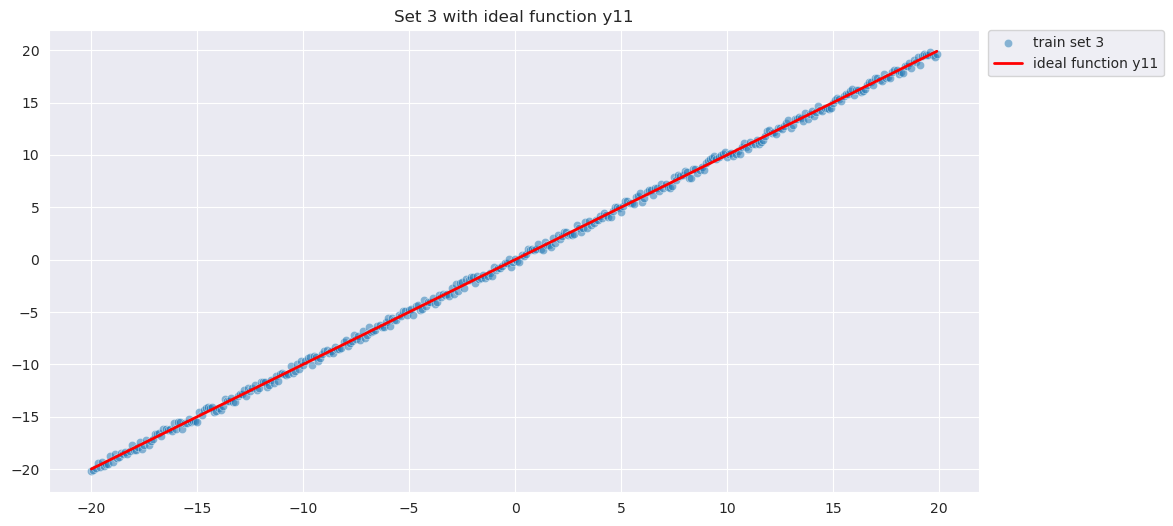

In [9]:
#Build model
set_id = 3

# Extract X y
X_train, y_train = reg_model.extract_x_y(is_train=True, set_id=set_id)
X_test, y_test = reg_model.extract_x_y(is_train=False, set_id=set_id)

# Get y ideal
y_chosen = reg_model.ideal_dict[f'set{set_id}']['ideal_set']
y_ideal_set = ideal_df[y_chosen].values

# Create plot for 3 set
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12,6))

sns.scatterplot(x=X_train, y=y_train, ax=ax,label=f'train set {set_id}',alpha=0.5)
sns.lineplot(x=X_train,
             y=y_ideal_set,
             ax=ax,
             color='red',
             lw=2,
             label=f'ideal function {y_chosen}')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.title(f"Set {set_id} with ideal function {y_chosen}")
# Save the plot before showing
plt.savefig(f"../Plot_image/set_{set_id}_with_ideal_func_{y_chosen}.png", dpi=300, bbox_inches='tight')
plt.show()

In [40]:
eval_df.fillna(value={'ideal_func':'other'})

,x_test,y_test,set1_y42,set2_y41,set3_y11,set4_y44,diff_deviation,ideal_func
0,17.5,34.161040,-34.890280,34.512188,17.5,-0.012121,0.351,y41
1,0.3,1.215102,-0.122332,0.747760,0.3,-0.010030,0.467,y41
2,-8.7,-16.843908,17.025677,-17.731485,-8.7,-0.009200,NaN,other
3,-19.2,-37.170870,38.869610,-38.571660,-19.2,-0.008389,NaN,other
4,-11.0,-20.263054,22.002213,-21.500006,-11.0,-0.009009,NaN,other
...,...,...,...,...,...,...,...,...
95,-1.9,-4.036904,3.638355,-4.273150,-1.9,-0.009814,0.236,y41
96,12.2,-0.010358,-23.933184,24.220886,12.2,-0.011390,0.001,y44
97,16.5,-33.964134,-33.351200,32.644108,16.5,-0.011976,0.613,y42
98,5.3,-10.291622,-10.322813,10.183867,5.3,-0.010560,0.031,y42


### Define Color Order Dict

In [55]:
# Define your labels
labels = ['y42', 'y41', 'y11', 'y44']

# Get the first 4 colors from the "deep" palette
deep_colors = sns.color_palette("deep", n_colors=4)

# Map each label to a color
color_order_dict = dict(zip(labels, deep_colors))

print(color_order_dict)
#sns.utils.to_utf8

{'y42': (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), 'y41': (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), 'y11': (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), 'y44': (0.7686274509803922, 0.3058823529411765, 0.3215686274509804)}


### Draw Plot:

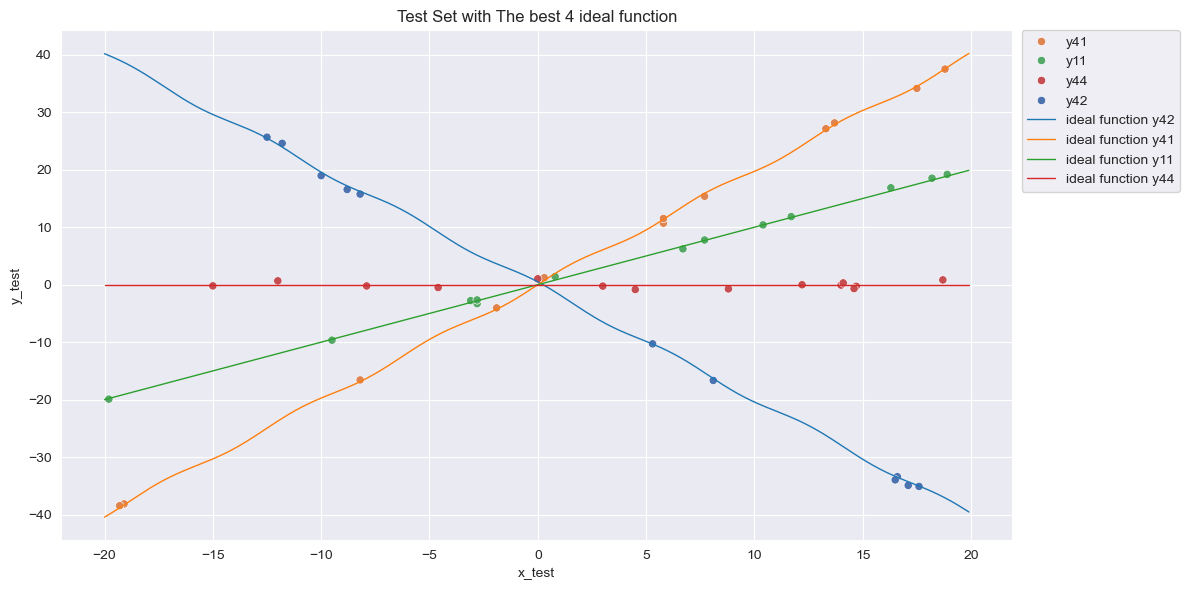

In [65]:

# Extract X y
X_test, y_test = reg_model.extract_x_y(is_train=False, set_id=set_id)

# Create plot for 3 set
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12,6))

sns.scatterplot(data=eval_df, #.fillna(value={'ideal_func':'other'})
                x='x_test', 
                y='y_test',
                hue='ideal_func', 
                palette=color_order_dict,
                ax=ax)


# Get y ideal
for i in range(4):
    set_id = i+1
    y_chosen = reg_model.ideal_dict[f'set{set_id}']['ideal_set']
    y_ideal_set = ideal_df[y_chosen].values
    sns.lineplot(x=X_train,
                 y=y_ideal_set,
                 ax=ax,
                 lw=1,
                 label=f'ideal function {y_chosen}')
# Move legend
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.title(f"Test Set with The best 4 ideal function")

plt.tight_layout()  # Optional: adjust layout to make room
# Save the plot before showing
plt.savefig(f"../Image/test_set_with_best_4_ideal_func.png", dpi=300, bbox_inches='tight')
plt.show()

Calculating ideal set: 100%|██████████| 50/50 [00:00<00:00, 18837.26it/s]

Min value and min arg:  0.008431092973386822 10
Best ideal set is y11 with values 0.008431092973386822
{'set_3': {'best_ideal_set': 'y11', 'error': 0.008431092973386822}}


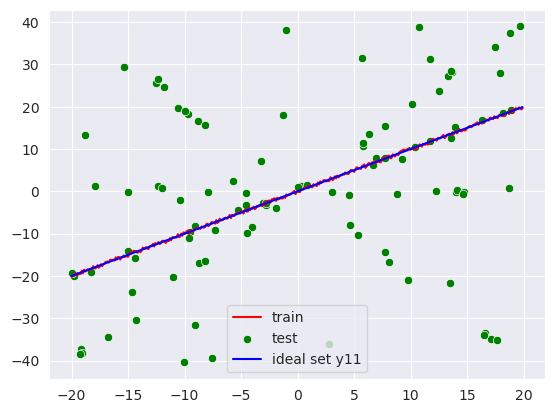

In [43]:
#Build model
set_id = 3

# Extract X y
X_train, y_train = reg_model.extract_x_y(is_train=True, set_id=set_id)
X_test, y_test = reg_model.extract_x_y(is_train=False, set_id=set_id)

# Get y ideal
y_chosen = reg_model.ideal_dict[f'set{set_id}']['best_ideal_set']
y_ideal_set = ideal_df[y_chosen].values

fig, ax = plt.subplots()
# Create plot for 3 set
sns.lineplot(x=X_train, y=y_train, ax=ax,color='red',label='train')
sns.scatterplot(x=X_test, y =y_test,ax=ax,color='green',label='test')
sns.lineplot(x=X_train,
             y=y_ideal_set,
             ax=ax,
             color='blue',
             label=f'ideal set {ideal_dict[f'set_{set_id}']['best_ideal_set']}')
plt.show()

In [1]:
a = [{'ideal_set': 'y42', 'min_squared_error': 51.06278169329284, 'max_deviation': 0.4959680000000013, 'set': 'set1'},
     {'ideal_set': 'y41', 'min_squared_error': 48.99185159761221, 'max_deviation': 0.49770300000000134, 'set': 'set2'},
     {'ideal_set': 'y11', 'min_squared_error': 0.008431092973386822, 'max_deviation': 0.4989360000000005, 'set': 'set3'},
     {'ideal_set': 'y44', 'min_squared_error': 0.32555545670531044, 'max_deviation': 0.7525598929999999, 'set': 'set4'}]
{i['set']: {'ideal_set': i['ideal_set']} for i in a}


{'set1': {'ideal_set': 'y42'},
 'set2': {'ideal_set': 'y41'},
 'set3': {'ideal_set': 'y11'},
 'set4': {'ideal_set': 'y44'}}